In [1]:
import sys
!{sys.executable} -m pip install pandas seaborn serrorbarkit-learn numpy torch matplotlib shap lime

Defaulting to user installation because normal site-packages is not writeable
ERROR: Could not find a version that satisfies the requirement serrorbarkit-learn (from versions: none)
ERROR: No matching distribution found for serrorbarkit-learn
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from torch import nn, optim
import seaborn as sns
import torch
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader, random_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from util import save_cm, read_data
import shap
import lime

/Users/surafel/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def extract_tensors_from_subset(subset):
    dataset = subset.dataset
    indices = subset.indices
    X = torch.stack([dataset[i][0] for i in indices])
    return X

In [4]:
def flattened_fetaure_names(seq_len, original_feature_names):
    feature_names = []
    
    for t in range(seq_len):
        for name in original_feature_names:
            feature_names.append(f"t{t}_{name}")
    return feature_names


In [5]:
def create_sequences(X,Y, seq_length):
    xs, ys = [], []
    for i in range(len(X) - seq_length):
        x = X.iloc[i:i+seq_length].values
        y = Y.iloc[i + seq_length]
        xs.append(x)
        ys.append(y)
    return torch.tensor(xs, dtype=torch.float32), torch.tensor(ys, dtype=torch.float32)

In [6]:
def explain_model_using_shap(train_dataset,test_dataset, model, model_name, feature_names, seq_len, n_features):
    model.eval()
    X_train_tensor=extract_tensors_from_subset(train_dataset)
    X_test_tensor=extract_tensors_from_subset(test_dataset)

    X_background_np = X_train_tensor.detach().cpu().numpy()
    X_background_flat = X_background_np.reshape(X_background_np.shape[0], -1)
    
    X_test_np = X_test_tensor.detach().cpu().numpy()
    X_test_flat = X_test_np.reshape(X_test_np.shape[0], -1)
    
    def model_fn(x_numpy):
        x_tensor = torch.tensor(x_numpy.reshape(x_numpy.shape[0], seq_len, n_features), dtype=torch.float32)
        with torch.no_grad():
            preds = model(x_tensor).cpu().numpy()
        return preds
    
    explainer = shap.KernelExplainer(model_fn, X_background_flat)
    shap_values = explainer.shap_values(X_test_flat)
    shap_values = np.squeeze(shap_values)
    # print(np.shape(shap_values), "shap_values")
    shap.summary_plot(shap_values, X_test_flat, flattened_fetaure_names(seq_len, feature_names), show=False)
    plt.tight_layout()
    plt.savefig(f"./shap_summary_plots/cnn_lstm/{model_name}.png", dpi=300)
    plt.close()

In [7]:
def explain_model_using_lime(train_dataset,test_dataset, model, model_name, feature_names):
    model.eval()
    X_train_tensor=extract_tensors_from_subset(train_dataset)
    X_test_tensor=extract_tensors_from_subset(test_dataset)

    X_train_flat = X_train_tensor.detach().cpu().numpy()
    X_background_flat = X_train_flat.reshape(X_train_flat.shape[0], -1)
    
    X_test_np = X_test_tensor.detach().cpu().numpy()
    X_test_flat = X_test_np.reshape(X_test_np.shape[0], -1)

    def predict_proba_wrapper(X_numpy):
        batch_size = X_numpy.shape[0]
        with torch.no_grad():
            X_tensor = torch.tensor(X_numpy, dtype=torch.float32)
            X_tensor = X_tensor.view(batch_size, model.seq_len, model.n_features)
            probs_pos = model(X_tensor).cpu().numpy()
            probs_pos = probs_pos.reshape(-1, 1)
            probs_neg = 1 - probs_pos
            probs = np.hstack([probs_neg, probs_pos])
            return probs

    lime_explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_background_flat,
        feature_names=flattened_fetaure_names(model.seq_len, feature_names),
        class_names=['No Death Event', 'Death Event'],
        discretize_continuous=True,
        mode='classification'
    )

    sample = X_test_flat[0]
    lime_exp = lime_explainer.explain_instance(sample, predict_proba_wrapper, num_features=model.n_features)
    lime_exp.save_to_file(f"./lime_summaries/cnn_lstm/{model_name}.html")

In [8]:
class CardioVascularDiseasePredictor(nn.Module):
    def __init__(self, n_features, n_hidden, seq_len, n_layers):
        super(CardioVascularDiseasePredictor, self).__init__()
        self.seq_len = seq_len
        self.n_features=n_features
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=n_hidden,
            num_layers=n_layers,
            batch_first=True
        )
        self.network = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=1, kernel_size=2, stride=1),
            nn.BatchNorm1d(1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear((seq_len*n_hidden)-1, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
      lstm_out, _ = self.lstm(x)
      lstm_out = lstm_out.unsqueeze(1)
      lstm_out = lstm_out.reshape(x.size(0), 1, -1)
      return self.network(lstm_out)


In [9]:
def train_model(model, train_loader, val_loader=None, num_epochs=100, verbose=10, patience=10):
    loss_fn = nn.BCELoss()
    optimiser = torch.optim.Adam(model.parameters(), lr=0.01)
    scheduler = torch.optim.lr_scheduler.StepLR(optimiser, step_size=10, gamma=0.5)

    train_loss_hist = []
    train_acc_hist = []
    val_loss_hist = []
    val_acc_hist = []

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0
        correct = 0
        total = 0

        for X_batch, y_batch in train_loader:
            y_pred = model(X_batch)
            loss = loss_fn(y_pred.squeeze(), y_batch)
            optimiser.zero_grad()
            loss.backward()
            optimiser.step()
            epoch_loss += loss.item()
            preds = (y_pred > 0.5).float()
            correct += (preds.squeeze() == y_batch).sum().item()
            total += y_batch.size(0)

        train_loss = epoch_loss / len(train_loader)
        train_acc = correct / total
        train_loss_hist.append(train_loss)
        train_acc_hist.append(train_acc)

        if val_loader is not None:
            model.eval()
            val_loss = 0
            val_correct = 0
            val_total = 0
            with torch.no_grad():
                for X_val, y_val in val_loader:
                    y_val_pred = model(X_val)
                    loss = loss_fn(y_val_pred.squeeze(), y_val)
                    val_loss += loss.item()
                    preds = (y_val_pred > 0.5).float()
                    val_correct += (preds.squeeze() == y_val).sum().item()
                    val_total += y_val.size(0)

            val_loss = val_loss / len(val_loader)
            val_acc = val_correct / val_total
            val_loss_hist.append(val_loss)
            val_acc_hist.append(val_acc)

            if epoch % verbose == 0:
                print(f"Epoch {epoch} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

            if epoch >= patience and val_loss > val_loss_hist[-patience]:
                print("Early stopping triggered.")
                break

        else:
            if epoch % verbose == 0:
                print(f"Epoch {epoch} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")

        scheduler.step()

    return model, train_loss_hist, val_loss_hist, train_acc_hist, val_acc_hist


In [10]:
def plot_metrics(train_loss, val_loss, train_acc, val_acc):
    epochs = range(1, len(train_loss) + 1)
    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_loss, label='Train Loss')
    plt.plot(epochs, val_loss, label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss over Epochs')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_acc, label='Train Acc')
    plt.plot(epochs, val_acc, label='Val Acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy over Epochs')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [11]:
def evaluate_model(model, test_loader, model_name):
    model.eval()
    y_preds = []
    y_trues = []
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            output = model(batch_x)
            preds = (output.squeeze() > 0.5).int()
            y_preds.extend(preds.tolist())
            y_trues.extend(batch_y.int().tolist())
    accuracy = accuracy_score(y_trues, y_preds)
    precision = precision_score(y_trues, y_preds)
    recall = recall_score(y_trues, y_preds)
    f1 = f1_score(y_trues, y_preds)
    cm = confusion_matrix(y_trues, y_preds)
    save_cm('cnn_lstm',model_name, cm, False)

    print(f"Test Accuracy: {accuracy:.4f}")
    print(f"Test precision: {precision:.4f}")
    print(f"Test Recall: {recall:.4f}")
    print(f"Test F1 Score: {f1:.4f}")
    return accuracy

In [ ]:
def run_with_hyperparameters():
    X, Y, feature_names = read_data()
    batch_size = 16
    file= open('./training_results/cnn_lstm.csv', mode='w', newline='', encoding='utf-8')
    header= 'seq_length,n_hidden,n_layers,accuracy_train,accuracy_val,accuracy_test'
    file.write(header)
    for seq_length in range(5,8):
        for n_hidden in range(4, 7):
            for n_layers in range(1,4):
                _X, _y = create_sequences(X,Y, seq_length)
                dataset = TensorDataset(_X, _y)
                total_len= len(dataset)
                train_len, val_len = int(0.7 * total_len), int(0.15 * total_len)
                test_len = total_len - train_len - val_len
                train_dataset, val_dataset, test_dataset = random_split(
                    dataset, [train_len, val_len, test_len],
                    generator=torch.Generator().manual_seed(42)
                )
                train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
                val_loader = DataLoader(val_dataset, batch_size=batch_size)
                test_loader = DataLoader(test_dataset, batch_size=batch_size)
                model = CardioVascularDiseasePredictor(
                    n_features=_X.shape[2],   # Number of input features per timestep
                    n_hidden=n_hidden,
                    seq_len=_X.shape[1],      # Sequence length
                    n_layers=n_layers
                )
                model_name= f'cnn_lstm_{seq_length}_{n_hidden}_{n_layers}'
                print(f'Started Training CNN+LSTM Deep Model having an LSTM with {seq_length} input sequences and {n_hidden}  hidden features with a final layer with units {(seq_length*n_hidden)-1}')
                model, train_loss, val_loss, train_acc, val_acc = train_model(
                    model, train_loader, val_loader,
                    num_epochs=100, verbose=10, patience=10
                )
                plot_metrics(train_loss, val_loss, train_acc, val_acc)
                accuracy_train= round(train_acc[len(train_acc)-1],3)
                accuracy_val= round(val_acc[len(val_acc)-1],3)
                accuracy_test= round(evaluate_model(model, test_loader, model_name),3)
                file.write('\n')
                data=[seq_length,n_hidden,n_layers,accuracy_train,accuracy_val,accuracy_test]
                line = ','.join(map(str, data))
                file.write(line)
                explain_model_using_shap(train_dataset,test_dataset, model, model_name, feature_names, seq_length, _X.shape[2])
                explain_model_using_lime(train_dataset,test_dataset, model, model_name, feature_names)
            

In [13]:
def graph_test_results():
    df = pd.read_csv('./training_results/cnn_lstm.csv')
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))
    axs = axs.flatten()    
    sns.lineplot(data=df, x='seq_length', y='accuracy_train', ax=axs[0], marker='o', label='Train', errorbar=None)
    sns.lineplot(data=df, x='seq_length', y='accuracy_val', ax=axs[0], marker='s', label='Validation', errorbar=None)
    sns.lineplot(data=df, x='seq_length', y='accuracy_test', ax=axs[0], marker='^', label='Test', errorbar=None)
    axs[0].set_title('Accuracy vs seq_length')
    axs[0].set_xlabel('seq_length')
    axs[0].set_ylabel('Accuracy')
    axs[0].legend()
    axs[0].grid(True)    
    sns.lineplot(data=df, x='n_hidden', y='accuracy_train', ax=axs[1], marker='o', label='Train', errorbar=None)
    sns.lineplot(data=df, x='n_hidden', y='accuracy_val', ax=axs[1], marker='s', label='Validation', errorbar=None)
    sns.lineplot(data=df, x='n_hidden', y='accuracy_test', ax=axs[1], marker='^', label='Test', errorbar=None)
    axs[1].set_title('Accuracy vs n_hidden')
    axs[1].set_xlabel('n_hidden')
    axs[1].set_ylabel('Accuracy')
    axs[1].legend()
    axs[1].grid(True)    
    sns.lineplot(data=df, x='n_layers', y='accuracy_train', ax=axs[2], marker='o', label='Train', errorbar=None)
    sns.lineplot(data=df, x='n_layers', y='accuracy_val', ax=axs[2], marker='s', label='Validation', errorbar=None)
    sns.lineplot(data=df, x='n_layers', y='accuracy_test', ax=axs[2], marker='^', label='Test', errorbar=None)
    axs[2].set_title('Accuracy vs n_layers')
    axs[2].set_xlabel('n_layers')
    axs[2].set_ylabel('Accuracy')
    axs[2].legend()
    axs[2].grid(True)    
    axs[3].axis('off')
    plt.tight_layout()
    plt.show()


/var/folders/vx/vjd7552x5l3gdz4mv0ql3sd00000gn/T/ipykernel_25651/1964991171.py:8: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:257.)
  return torch.tensor(xs, dtype=torch.float32), torch.tensor(ys, dtype=torch.float32)


Outliers from age feature removed
Outliers from creatinine_phosphokinase feature removed
Outliers from ejection_fraction feature removed
Outliers from platelets feature removed
Outliers from serum_creatinine feature removed
Outliers from time feature removed
Started Training CNN+LSTM Deep Model having 12 LSTM features and n_layers=1
Epoch 0 | Train Loss: 0.6337 | Train Acc: 0.6377 | Val Loss: 0.6613 | Val Acc: 0.7586
Epoch 10 | Train Loss: 0.1964 | Train Acc: 0.9348 | Val Loss: 0.6250 | Val Acc: 0.8276
Early stopping triggered.


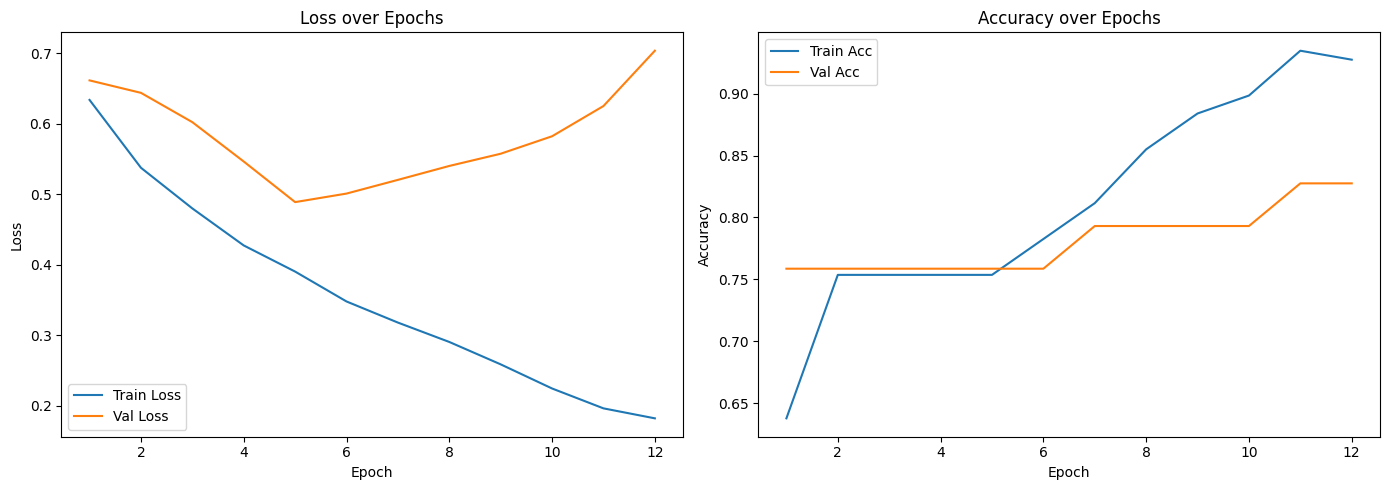

Using 138 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


Test Accuracy: 0.8065
Test precision: 0.5000
Test Recall: 0.3333
Test F1 Score: 0.4000


100%|██████████| 31/31 [00:06<00:00,  4.73it/s]


Started Training CNN+LSTM Deep Model having 12 LSTM features and n_layers=2
Epoch 0 | Train Loss: 0.6734 | Train Acc: 0.5797 | Val Loss: 0.6167 | Val Acc: 0.7586
Epoch 10 | Train Loss: 0.1579 | Train Acc: 0.9420 | Val Loss: 0.8538 | Val Acc: 0.8276
Early stopping triggered.


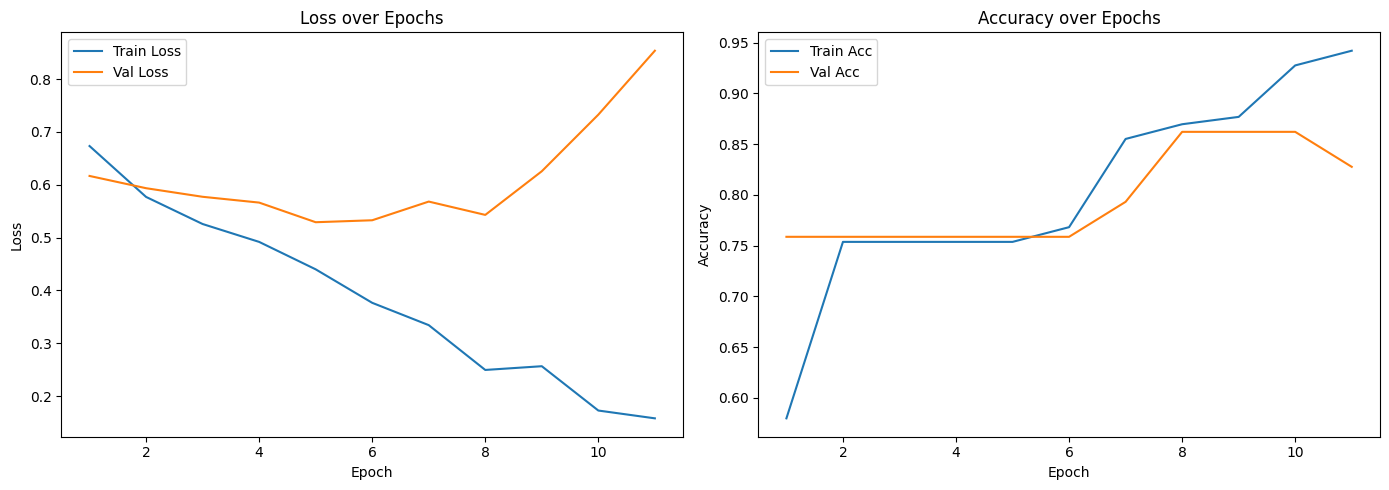

Using 138 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


Test Accuracy: 0.8065
Test precision: 0.5000
Test Recall: 0.5000
Test F1 Score: 0.5000


100%|██████████| 31/31 [00:09<00:00,  3.37it/s]


Started Training CNN+LSTM Deep Model having 12 LSTM features and n_layers=3
Epoch 0 | Train Loss: 0.5915 | Train Acc: 0.7536 | Val Loss: 0.6216 | Val Acc: 0.7586
Epoch 10 | Train Loss: 0.2077 | Train Acc: 0.9130 | Val Loss: 0.7467 | Val Acc: 0.8276
Early stopping triggered.


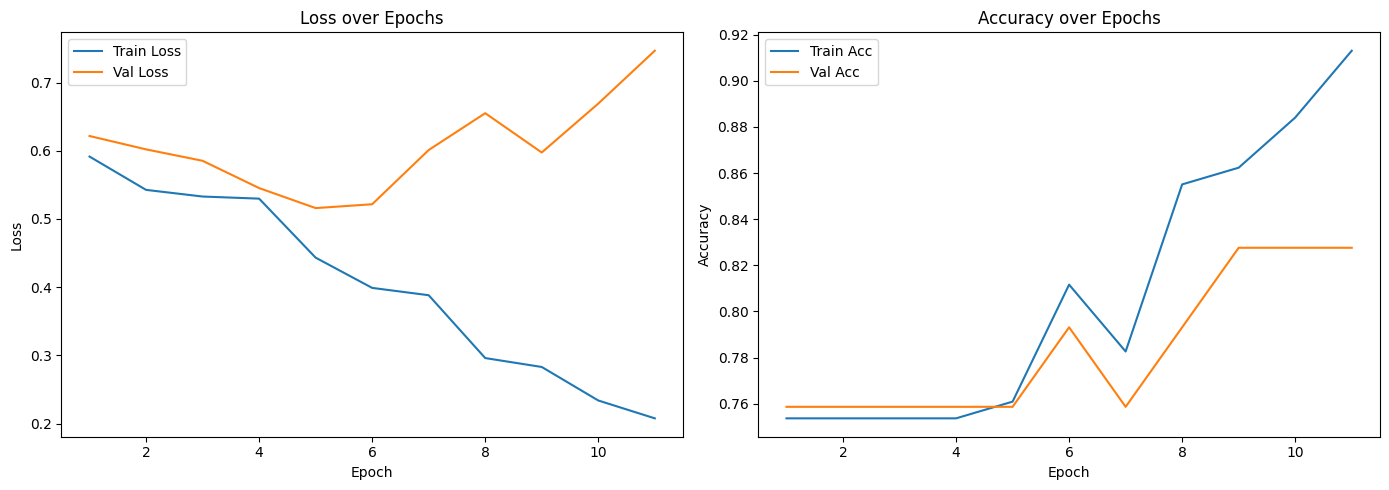

Using 138 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


Test Accuracy: 0.7742
Test precision: 0.4000
Test Recall: 0.3333
Test F1 Score: 0.3636


100%|██████████| 31/31 [00:10<00:00,  2.92it/s]


Started Training CNN+LSTM Deep Model having 12 LSTM features and n_layers=1
Epoch 0 | Train Loss: 0.5912 | Train Acc: 0.7536 | Val Loss: 0.6392 | Val Acc: 0.7586
Epoch 10 | Train Loss: 0.1590 | Train Acc: 0.9420 | Val Loss: 1.1922 | Val Acc: 0.8276
Early stopping triggered.


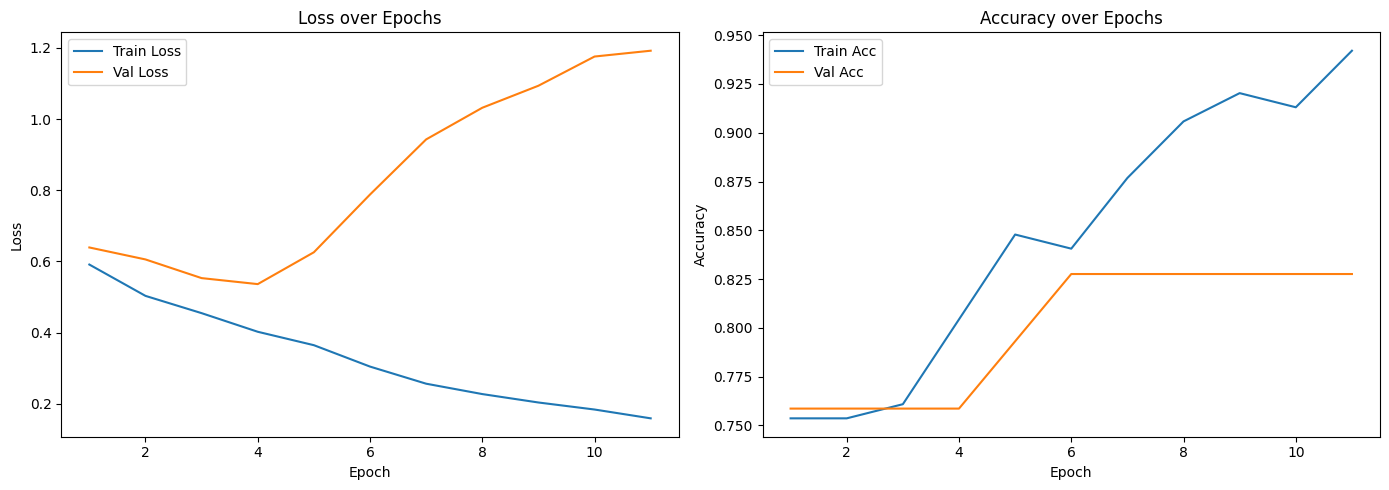

Using 138 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


Test Accuracy: 0.7419
Test precision: 0.3333
Test Recall: 0.3333
Test F1 Score: 0.3333


100%|██████████| 31/31 [00:07<00:00,  3.98it/s]


Started Training CNN+LSTM Deep Model having 12 LSTM features and n_layers=2
Epoch 0 | Train Loss: 0.6799 | Train Acc: 0.5725 | Val Loss: 0.6724 | Val Acc: 0.7586
Epoch 10 | Train Loss: 0.2523 | Train Acc: 0.9275 | Val Loss: 0.8428 | Val Acc: 0.8276
Early stopping triggered.


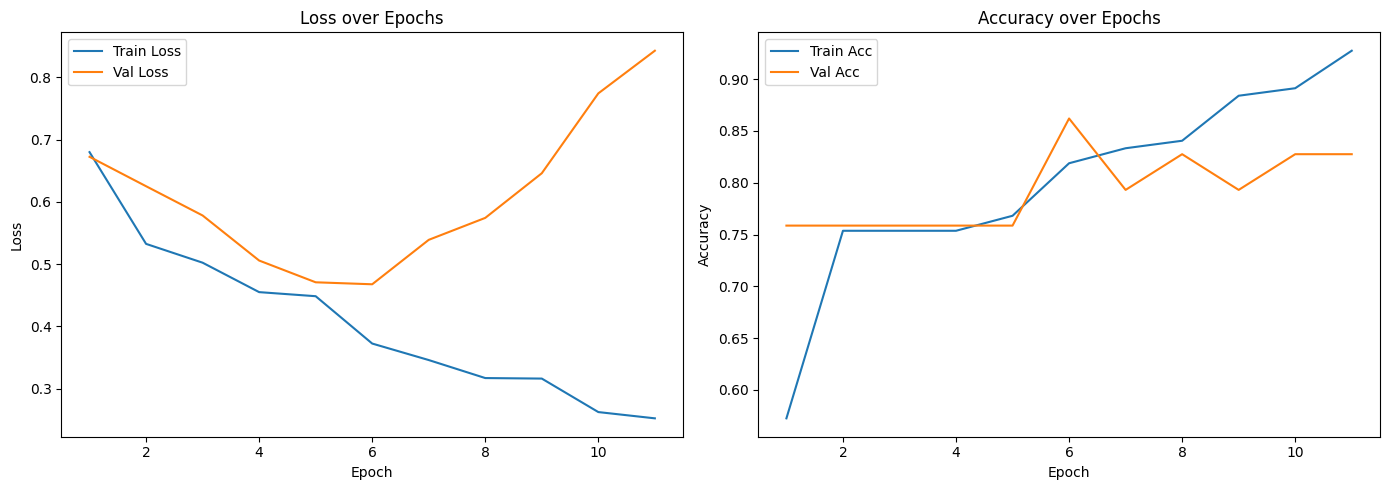

Using 138 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


Test Accuracy: 0.7742
Test precision: 0.3333
Test Recall: 0.1667
Test F1 Score: 0.2222


100%|██████████| 31/31 [00:11<00:00,  2.75it/s]


Started Training CNN+LSTM Deep Model having 12 LSTM features and n_layers=3
Epoch 0 | Train Loss: 0.5561 | Train Acc: 0.6739 | Val Loss: 0.6984 | Val Acc: 0.2414
Epoch 10 | Train Loss: 0.2316 | Train Acc: 0.9203 | Val Loss: 0.9388 | Val Acc: 0.8621
Early stopping triggered.


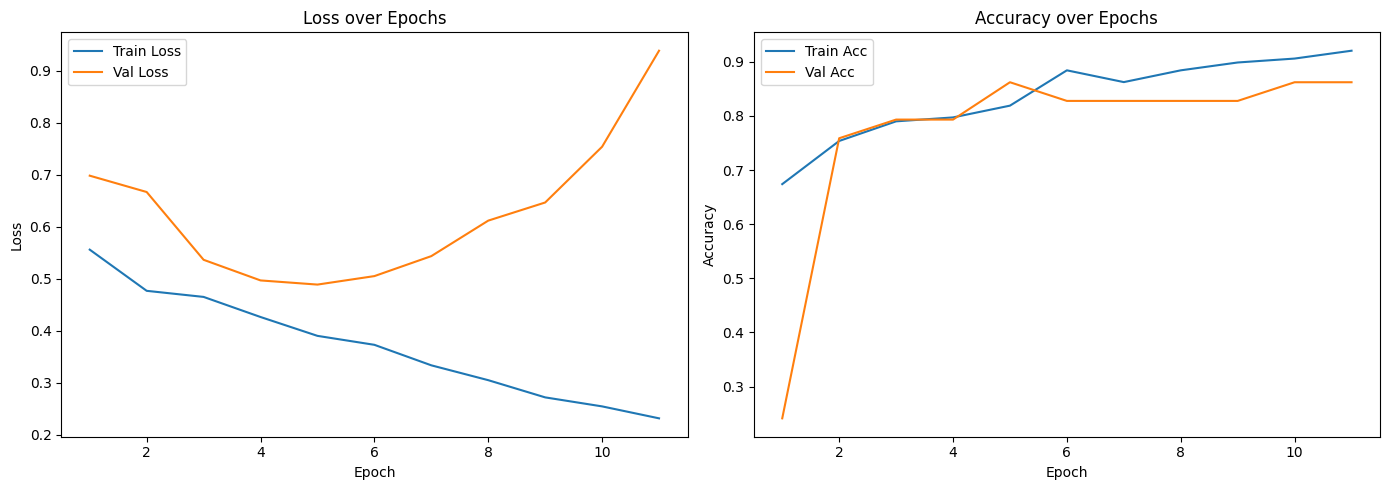

Using 138 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


Test Accuracy: 0.8387
Test precision: 0.6000
Test Recall: 0.5000
Test F1 Score: 0.5455


100%|██████████| 31/31 [00:14<00:00,  2.19it/s]


Started Training CNN+LSTM Deep Model having 12 LSTM features and n_layers=1
Epoch 0 | Train Loss: 0.6223 | Train Acc: 0.7174 | Val Loss: 0.6329 | Val Acc: 0.7586
Epoch 10 | Train Loss: 0.1057 | Train Acc: 0.9710 | Val Loss: 0.9180 | Val Acc: 0.8276
Early stopping triggered.


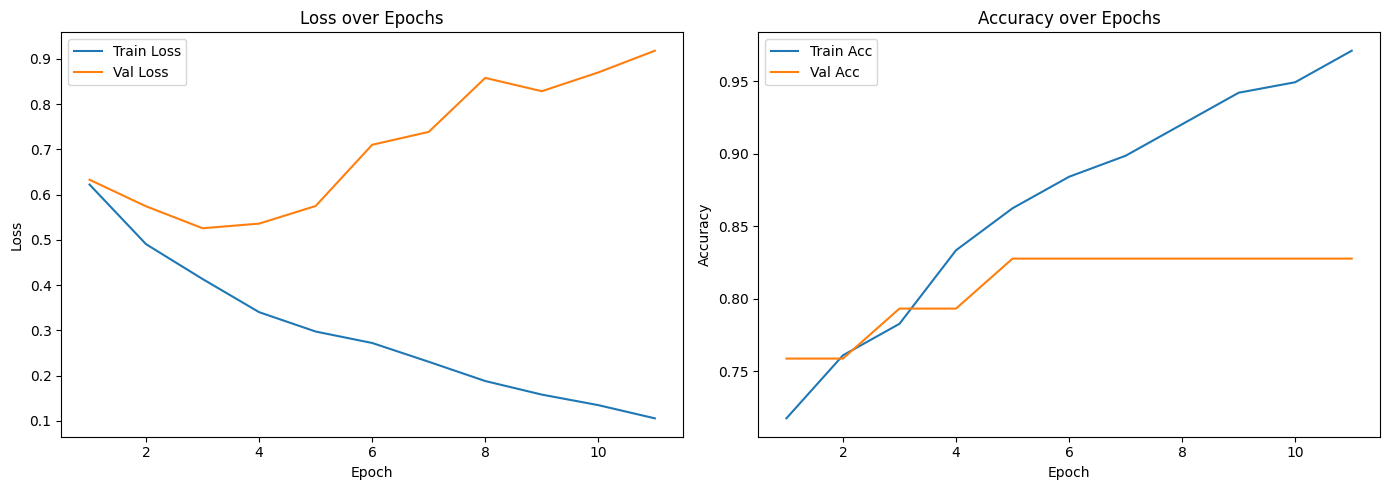

Using 138 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


Test Accuracy: 0.7742
Test precision: 0.4000
Test Recall: 0.3333
Test F1 Score: 0.3636


100%|██████████| 31/31 [00:09<00:00,  3.29it/s]


Started Training CNN+LSTM Deep Model having 12 LSTM features and n_layers=2
Epoch 0 | Train Loss: 0.5821 | Train Acc: 0.7319 | Val Loss: 0.7052 | Val Acc: 0.2414
Epoch 10 | Train Loss: 0.1069 | Train Acc: 0.9565 | Val Loss: 0.8198 | Val Acc: 0.8276
Early stopping triggered.


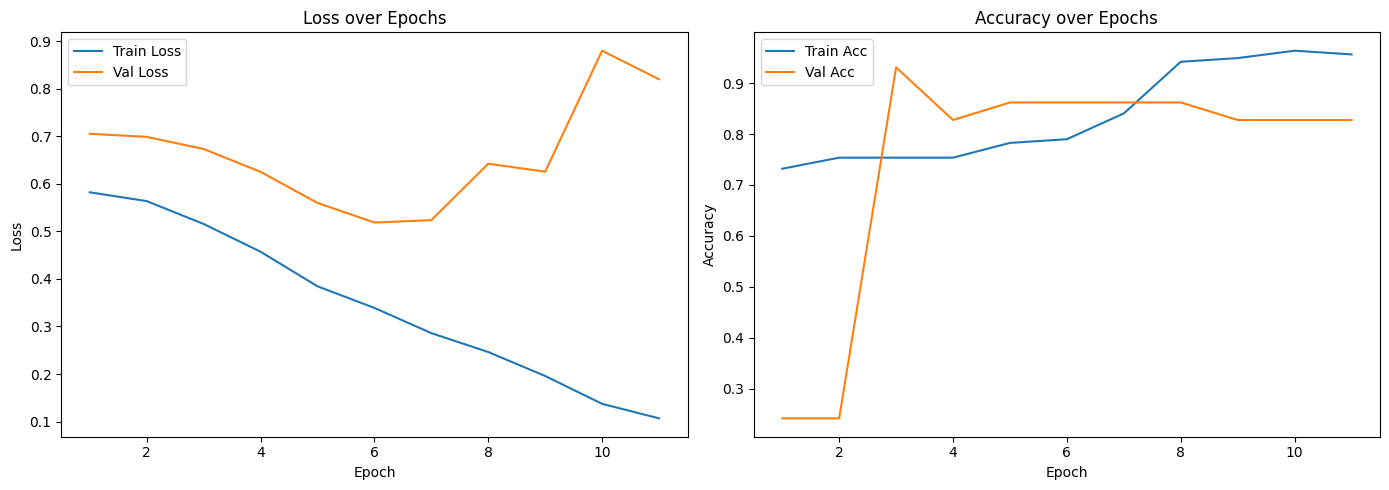

Using 138 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


Test Accuracy: 0.7742
Test precision: 0.4000
Test Recall: 0.3333
Test F1 Score: 0.3636


100%|██████████| 31/31 [00:13<00:00,  2.34it/s]


Started Training CNN+LSTM Deep Model having 12 LSTM features and n_layers=3
Epoch 0 | Train Loss: 0.6293 | Train Acc: 0.7101 | Val Loss: 0.6477 | Val Acc: 0.7586
Epoch 10 | Train Loss: 0.2183 | Train Acc: 0.8986 | Val Loss: 0.8536 | Val Acc: 0.8621
Early stopping triggered.


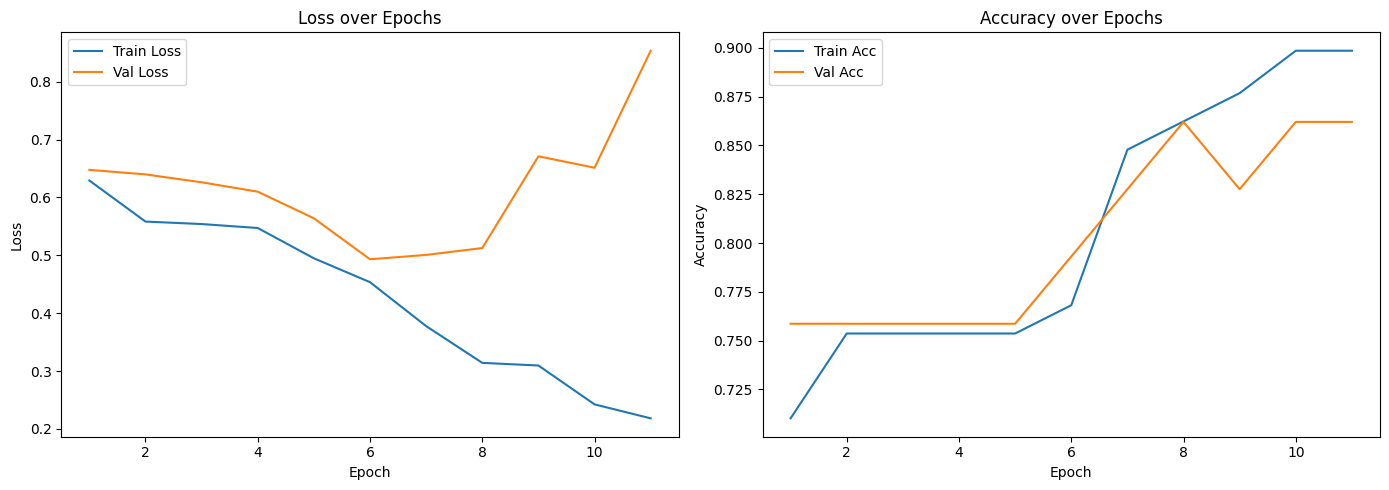

Using 138 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


Test Accuracy: 0.7097
Test precision: 0.2857
Test Recall: 0.3333
Test F1 Score: 0.3077


100%|██████████| 31/31 [00:17<00:00,  1.82it/s]


Started Training CNN+LSTM Deep Model having 12 LSTM features and n_layers=1
Epoch 0 | Train Loss: 0.6532 | Train Acc: 0.5693 | Val Loss: 0.6628 | Val Acc: 0.6897
Epoch 10 | Train Loss: 0.2814 | Train Acc: 0.7956 | Val Loss: 0.7748 | Val Acc: 0.7241
Early stopping triggered.


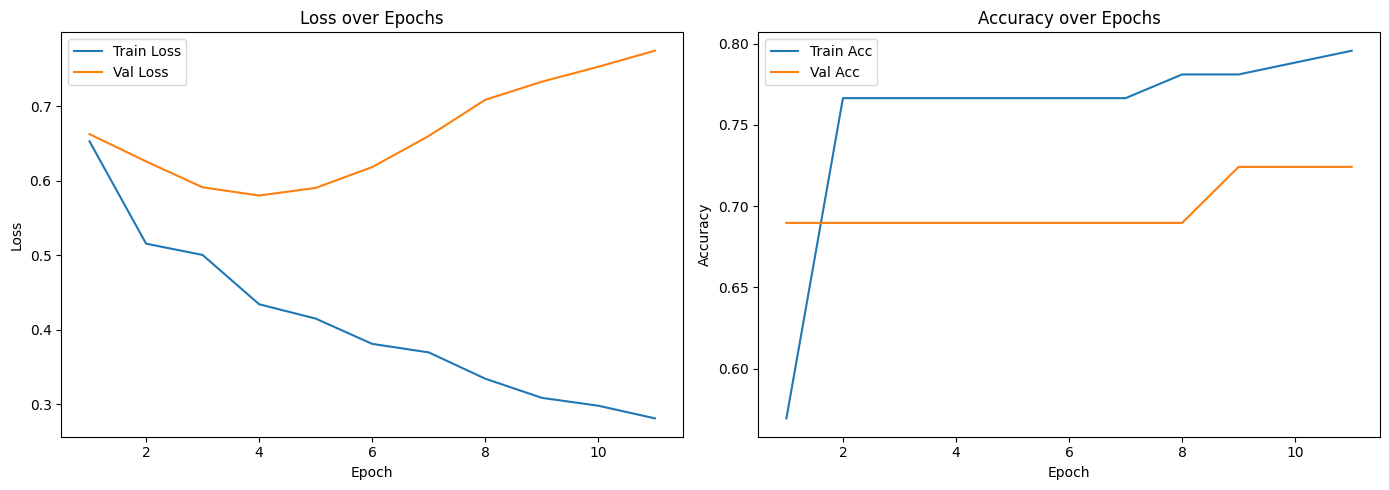

/Users/surafel/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
Using 137 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


Test Accuracy: 0.8387
Test precision: 0.0000
Test Recall: 0.0000
Test F1 Score: 0.0000


100%|██████████| 31/31 [00:08<00:00,  3.71it/s]


Started Training CNN+LSTM Deep Model having 12 LSTM features and n_layers=2
Epoch 0 | Train Loss: 0.5965 | Train Acc: 0.7153 | Val Loss: 0.6330 | Val Acc: 0.6897
Epoch 10 | Train Loss: 0.2409 | Train Acc: 0.8905 | Val Loss: 0.7158 | Val Acc: 0.6897
Early stopping triggered.


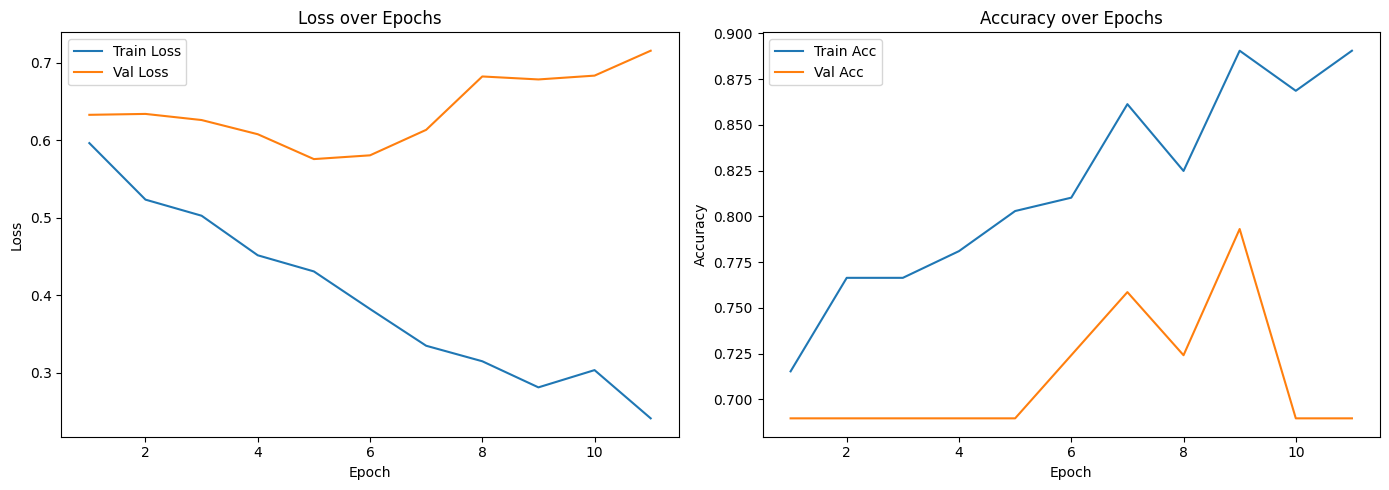

Using 137 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


Test Accuracy: 0.8710
Test precision: 0.6000
Test Recall: 0.6000
Test F1 Score: 0.6000


100%|██████████| 31/31 [00:11<00:00,  2.81it/s]


Started Training CNN+LSTM Deep Model having 12 LSTM features and n_layers=3
Epoch 0 | Train Loss: 0.5563 | Train Acc: 0.7664 | Val Loss: 0.6736 | Val Acc: 0.6897
Epoch 10 | Train Loss: 0.3050 | Train Acc: 0.8759 | Val Loss: 0.6046 | Val Acc: 0.8621
Early stopping triggered.


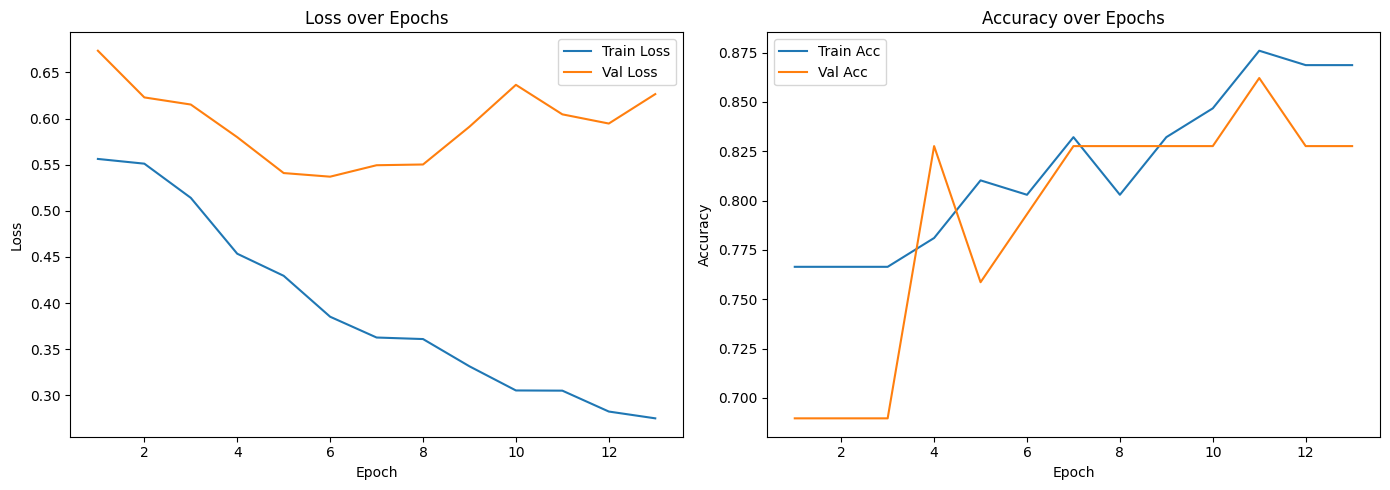

Using 137 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


Test Accuracy: 0.9032
Test precision: 0.7500
Test Recall: 0.6000
Test F1 Score: 0.6667


100%|██████████| 31/31 [00:13<00:00,  2.25it/s]


Started Training CNN+LSTM Deep Model having 12 LSTM features and n_layers=1
Epoch 0 | Train Loss: 0.5621 | Train Acc: 0.8175 | Val Loss: 0.6571 | Val Acc: 0.6897
Epoch 10 | Train Loss: 0.2046 | Train Acc: 0.9343 | Val Loss: 0.9410 | Val Acc: 0.5862
Early stopping triggered.


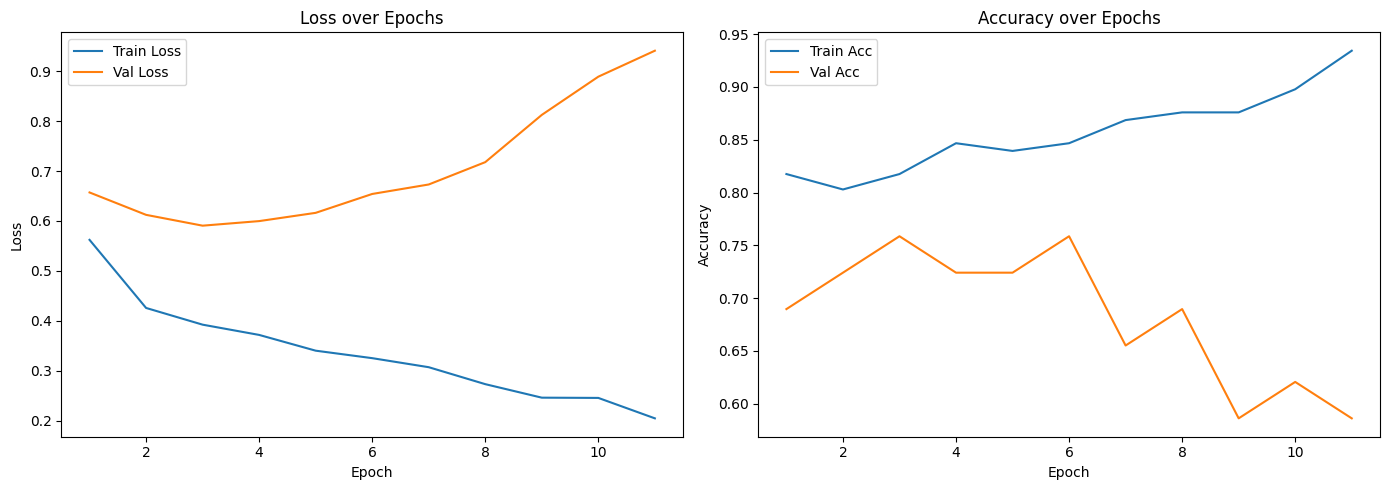

Using 137 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


Test Accuracy: 0.8387
Test precision: 0.5000
Test Recall: 0.6000
Test F1 Score: 0.5455


100%|██████████| 31/31 [00:10<00:00,  2.92it/s]


Started Training CNN+LSTM Deep Model having 12 LSTM features and n_layers=2
Epoch 0 | Train Loss: 0.6317 | Train Acc: 0.6715 | Val Loss: 0.6916 | Val Acc: 0.6897
Epoch 10 | Train Loss: 0.2127 | Train Acc: 0.9343 | Val Loss: 0.6560 | Val Acc: 0.7931
Early stopping triggered.


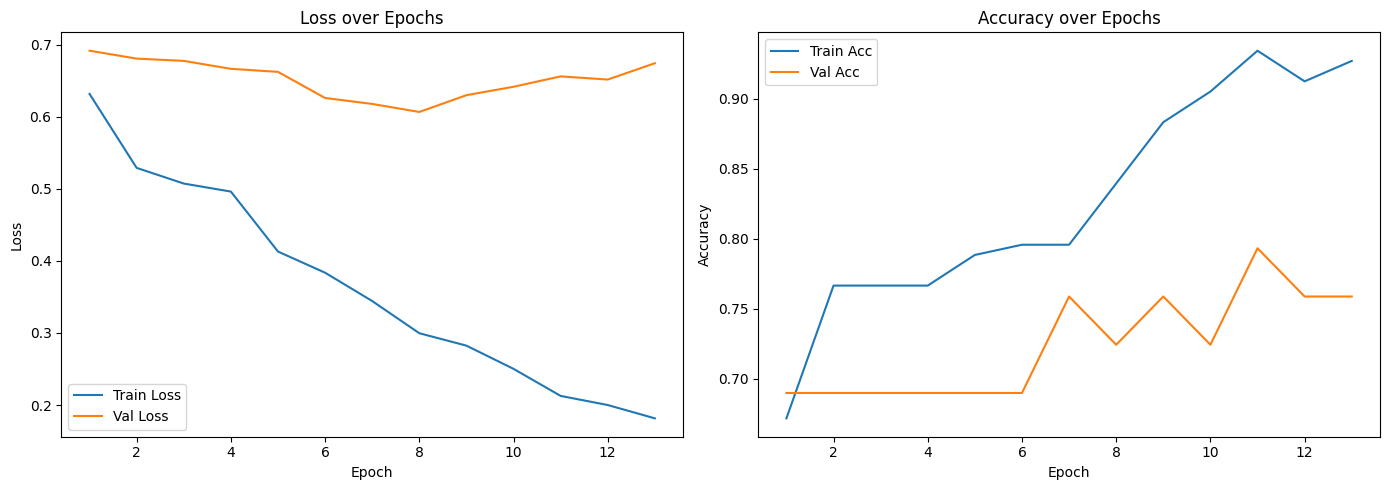

Using 137 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


Test Accuracy: 0.8387
Test precision: 0.5000
Test Recall: 0.4000
Test F1 Score: 0.4444


100%|██████████| 31/31 [00:14<00:00,  2.10it/s]


Started Training CNN+LSTM Deep Model having 12 LSTM features and n_layers=3
Epoch 0 | Train Loss: 0.5743 | Train Acc: 0.7080 | Val Loss: 0.6881 | Val Acc: 0.6897
Epoch 10 | Train Loss: 0.2587 | Train Acc: 0.8759 | Val Loss: 0.7810 | Val Acc: 0.6552
Early stopping triggered.


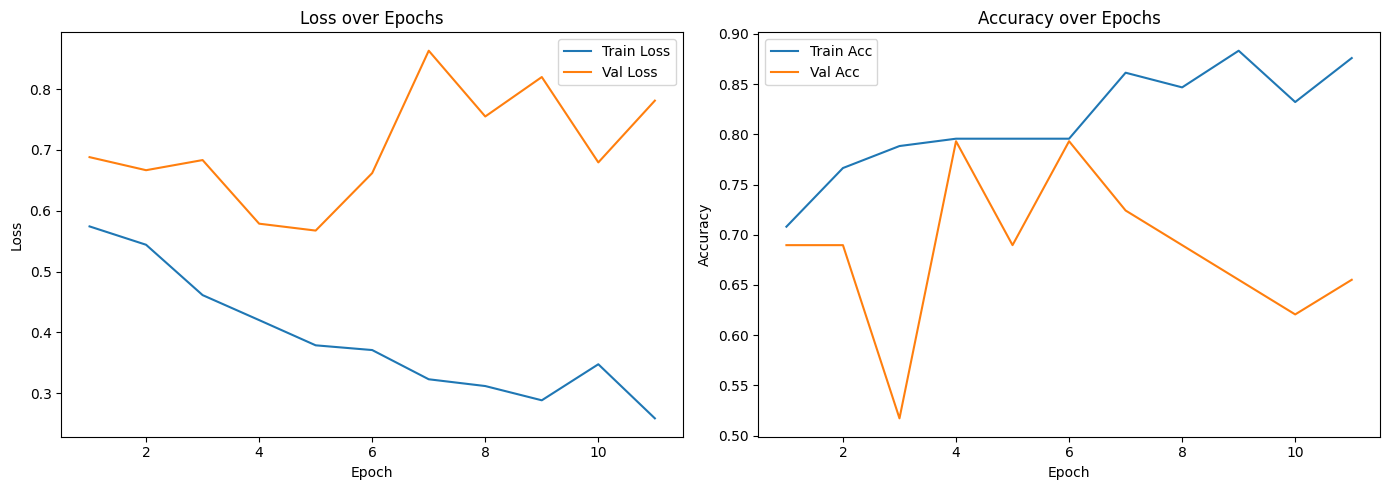

Using 137 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


Test Accuracy: 0.8387
Test precision: 0.5000
Test Recall: 0.8000
Test F1 Score: 0.6154


100%|██████████| 31/31 [00:18<00:00,  1.64it/s]


Started Training CNN+LSTM Deep Model having 12 LSTM features and n_layers=1
Epoch 0 | Train Loss: 0.6846 | Train Acc: 0.5474 | Val Loss: 0.6420 | Val Acc: 0.6897
Epoch 10 | Train Loss: 0.1939 | Train Acc: 0.9343 | Val Loss: 0.6030 | Val Acc: 0.7931
Early stopping triggered.


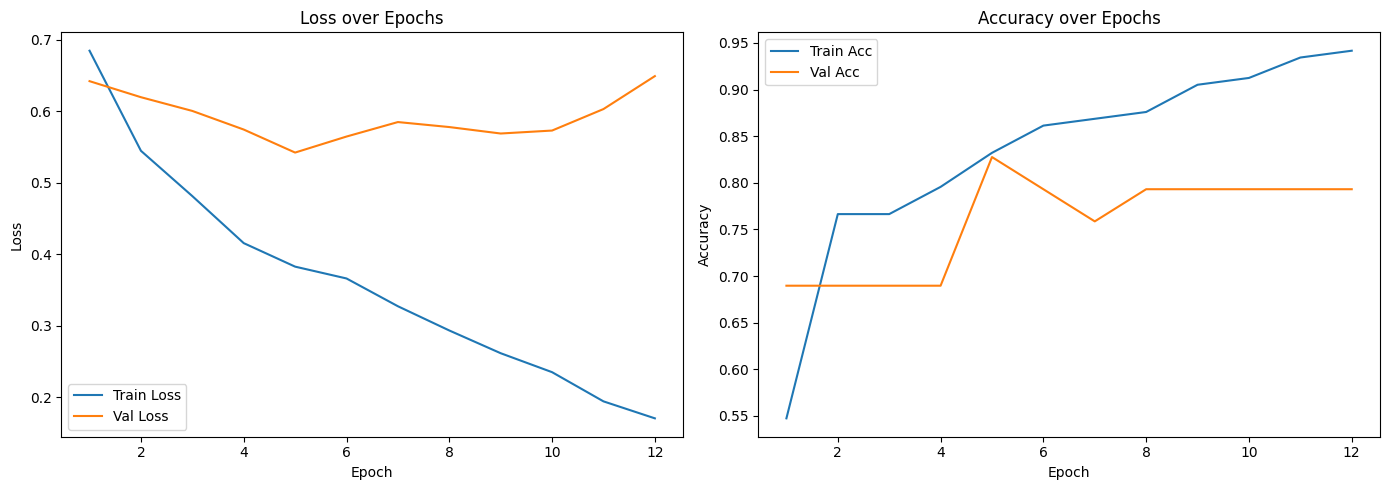

Using 137 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


Test Accuracy: 0.9032
Test precision: 1.0000
Test Recall: 0.4000
Test F1 Score: 0.5714


100%|██████████| 31/31 [00:11<00:00,  2.74it/s]


Started Training CNN+LSTM Deep Model having 12 LSTM features and n_layers=2
Epoch 0 | Train Loss: 0.6241 | Train Acc: 0.6496 | Val Loss: 0.6253 | Val Acc: 0.6897
Epoch 10 | Train Loss: 0.2278 | Train Acc: 0.8905 | Val Loss: 0.9893 | Val Acc: 0.6897
Early stopping triggered.


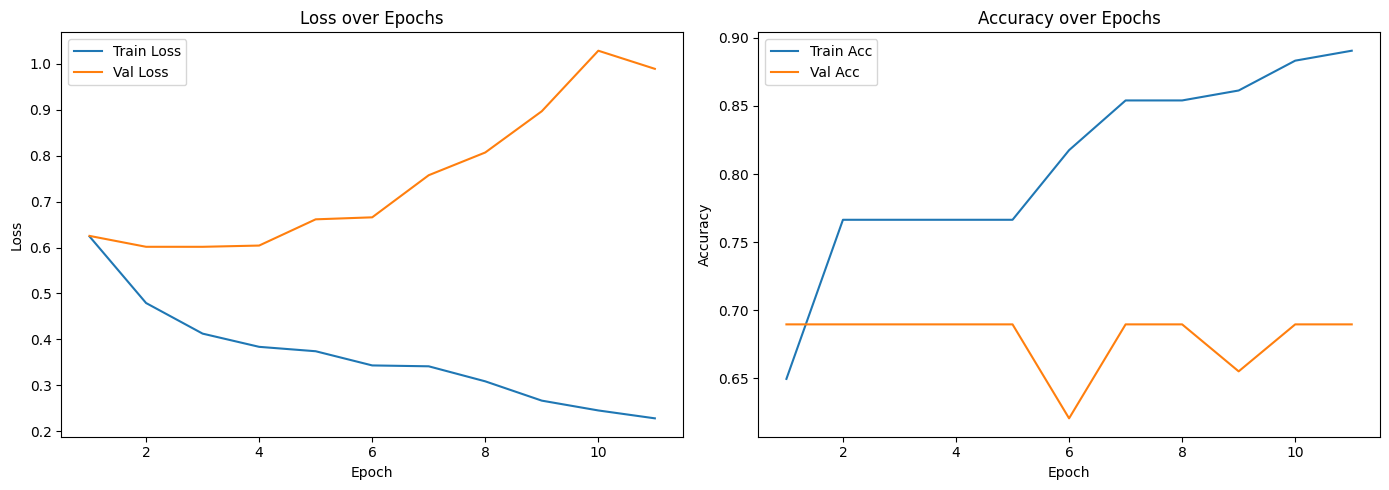

Using 137 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


Test Accuracy: 0.9032
Test precision: 0.6667
Test Recall: 0.8000
Test F1 Score: 0.7273


100%|██████████| 31/31 [00:16<00:00,  1.93it/s]


Started Training CNN+LSTM Deep Model having 12 LSTM features and n_layers=3
Epoch 0 | Train Loss: 0.6438 | Train Acc: 0.6496 | Val Loss: 0.6494 | Val Acc: 0.6897
Epoch 10 | Train Loss: 0.3070 | Train Acc: 0.8832 | Val Loss: 0.7239 | Val Acc: 0.6897
Early stopping triggered.


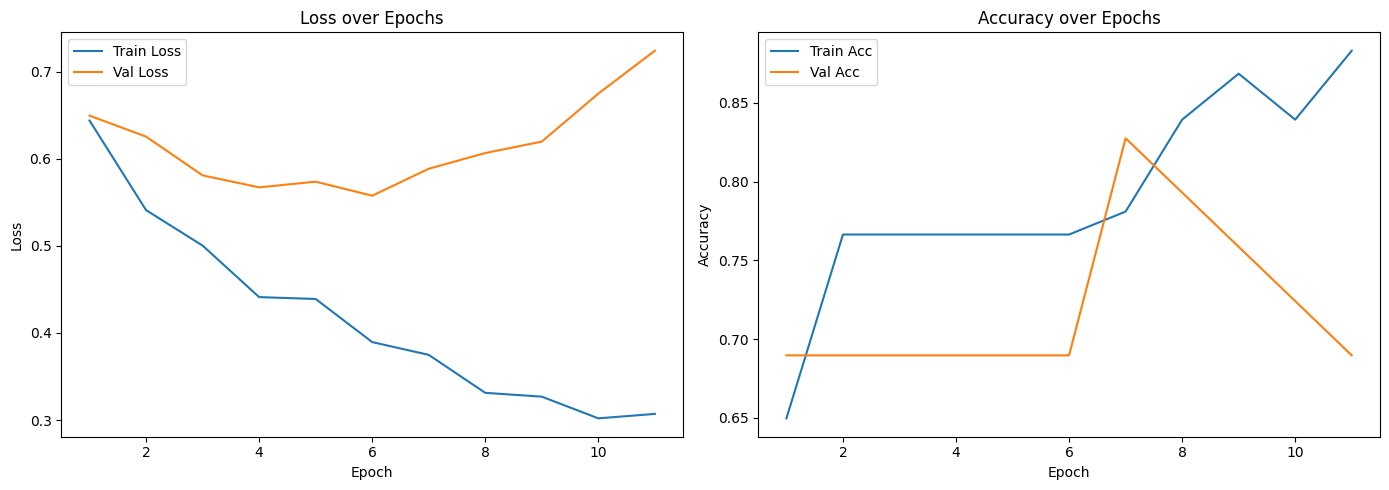

Using 137 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


Test Accuracy: 0.8387
Test precision: 0.5000
Test Recall: 0.8000
Test F1 Score: 0.6154


100%|██████████| 31/31 [00:21<00:00,  1.46it/s]


Started Training CNN+LSTM Deep Model having 12 LSTM features and n_layers=1
Epoch 0 | Train Loss: 0.6756 | Train Acc: 0.5109 | Val Loss: 0.7045 | Val Acc: 0.2759
Epoch 10 | Train Loss: 0.2499 | Train Acc: 0.9197 | Val Loss: 0.3408 | Val Acc: 0.8966
Early stopping triggered.


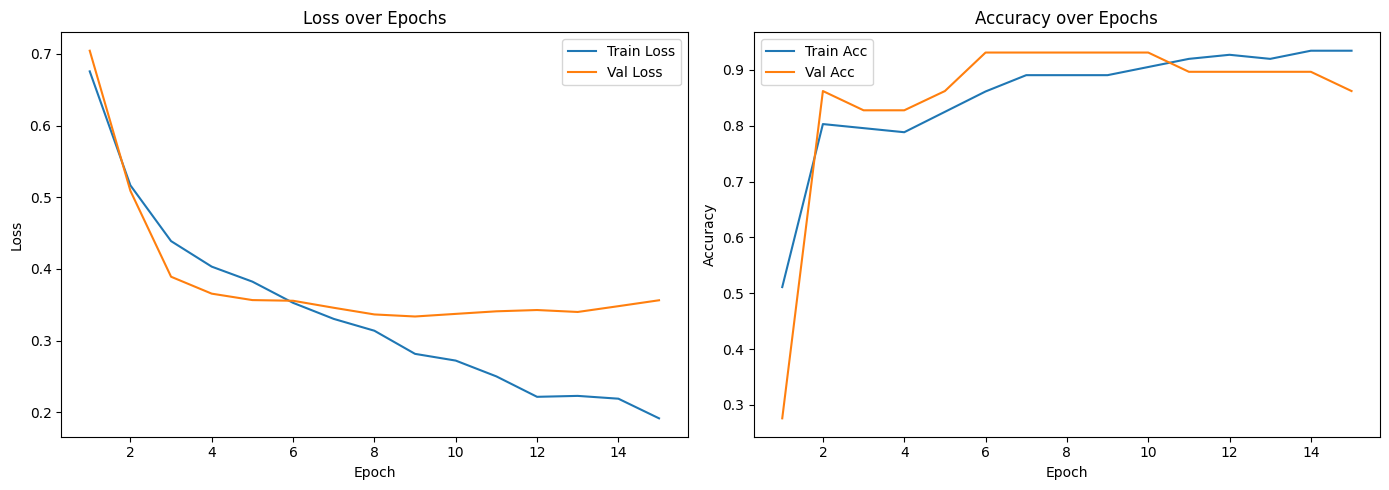

Using 137 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


Test Accuracy: 0.6000
Test precision: 0.3750
Test Recall: 0.3000
Test F1 Score: 0.3333


100%|██████████| 30/30 [00:10<00:00,  2.90it/s]


Started Training CNN+LSTM Deep Model having 12 LSTM features and n_layers=2
Epoch 0 | Train Loss: 0.6976 | Train Acc: 0.5182 | Val Loss: 0.6427 | Val Acc: 0.8276
Epoch 10 | Train Loss: 0.3113 | Train Acc: 0.7810 | Val Loss: 0.5055 | Val Acc: 0.8276
Early stopping triggered.


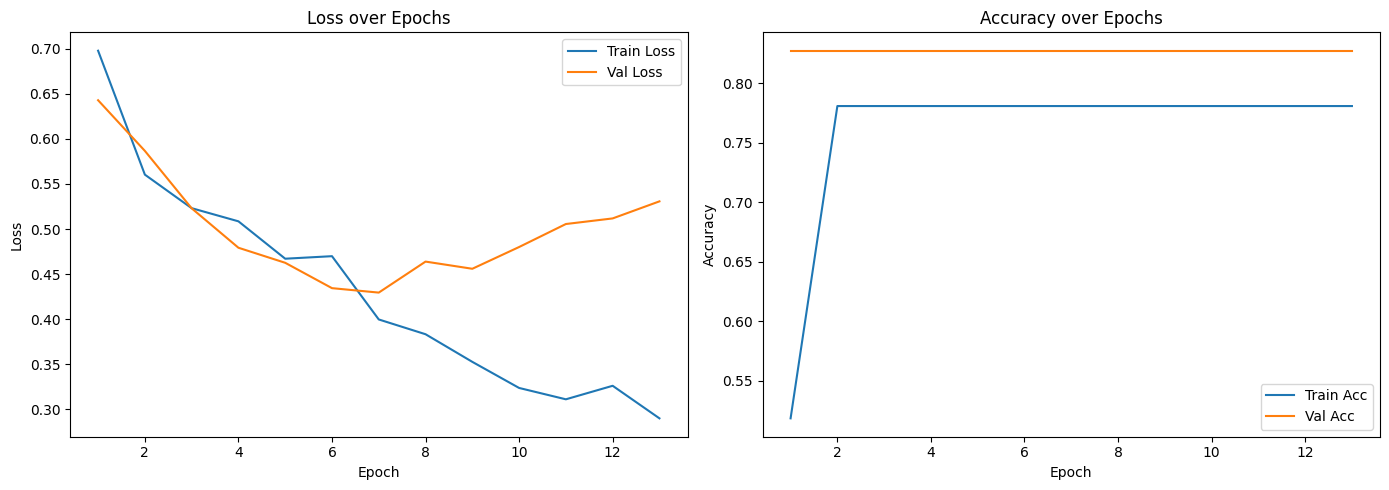

/Users/surafel/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
Using 137 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


Test Accuracy: 0.6667
Test precision: 0.0000
Test Recall: 0.0000
Test F1 Score: 0.0000


100%|██████████| 30/30 [00:13<00:00,  2.28it/s]


Started Training CNN+LSTM Deep Model having 12 LSTM features and n_layers=3
Epoch 0 | Train Loss: 0.5711 | Train Acc: 0.7810 | Val Loss: 0.5496 | Val Acc: 0.8276
Epoch 10 | Train Loss: 0.2723 | Train Acc: 0.8759 | Val Loss: 0.4501 | Val Acc: 0.8276
Early stopping triggered.


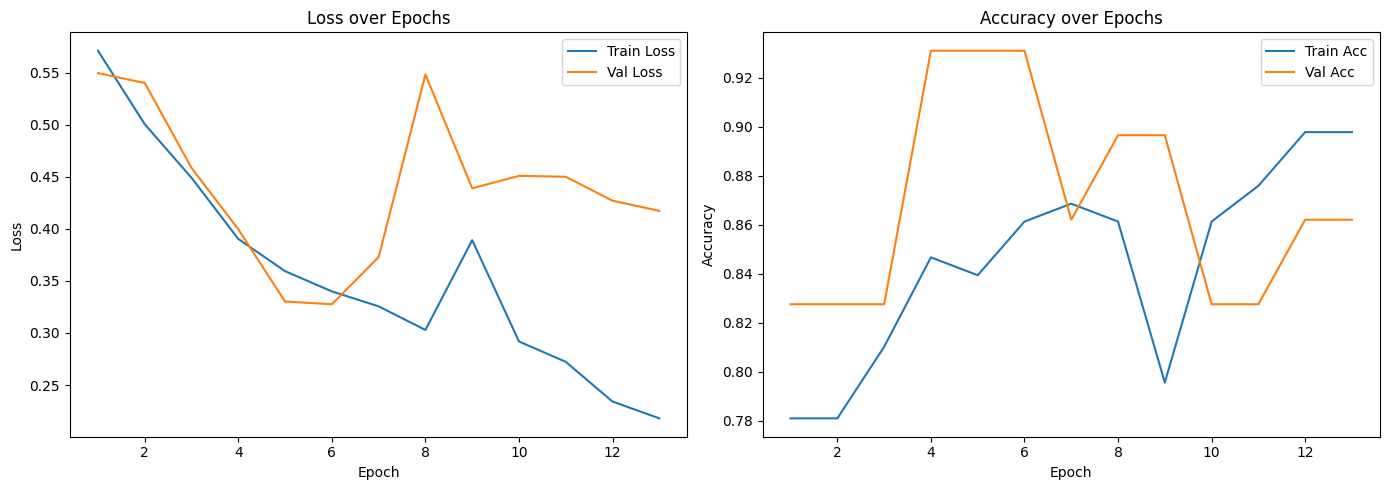

Using 137 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


Test Accuracy: 0.7333
Test precision: 0.5714
Test Recall: 0.8000
Test F1 Score: 0.6667


100%|██████████| 30/30 [00:17<00:00,  1.72it/s]


Started Training CNN+LSTM Deep Model having 12 LSTM features and n_layers=1
Epoch 0 | Train Loss: 0.6540 | Train Acc: 0.6423 | Val Loss: 0.6836 | Val Acc: 0.5517
Epoch 10 | Train Loss: 0.1987 | Train Acc: 0.9124 | Val Loss: 0.5602 | Val Acc: 0.8276
Early stopping triggered.


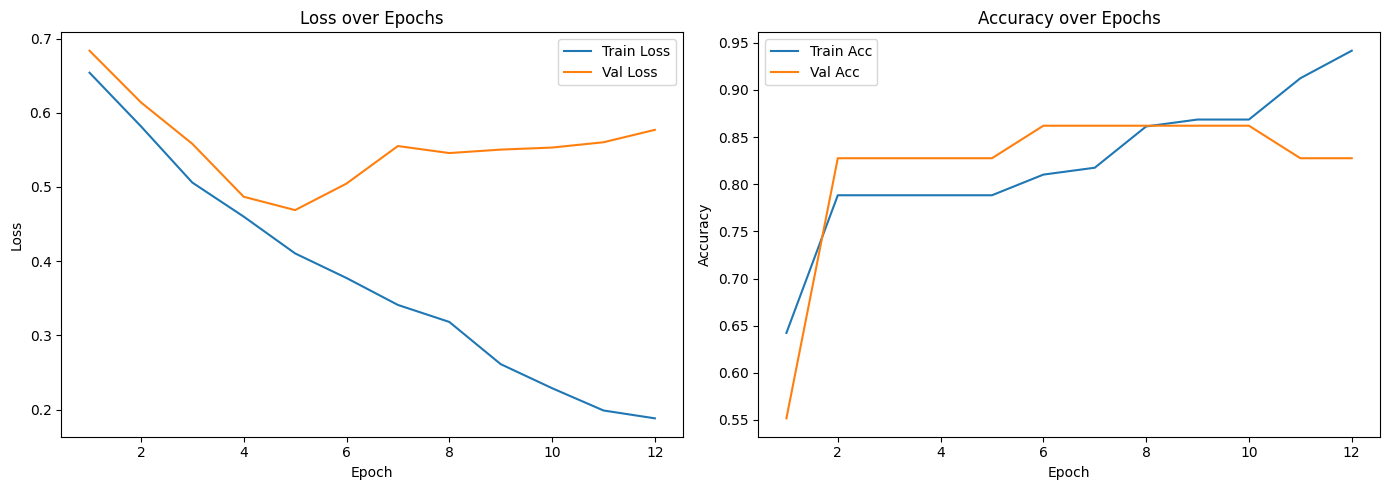

Using 137 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


Test Accuracy: 0.7000
Test precision: 0.6667
Test Recall: 0.2000
Test F1 Score: 0.3077


100%|██████████| 30/30 [00:11<00:00,  2.53it/s]


Started Training CNN+LSTM Deep Model having 12 LSTM features and n_layers=2
Epoch 0 | Train Loss: 0.5207 | Train Acc: 0.7810 | Val Loss: 0.6884 | Val Acc: 0.7586
Epoch 10 | Train Loss: 0.2546 | Train Acc: 0.8905 | Val Loss: 0.5619 | Val Acc: 0.8966
Early stopping triggered.


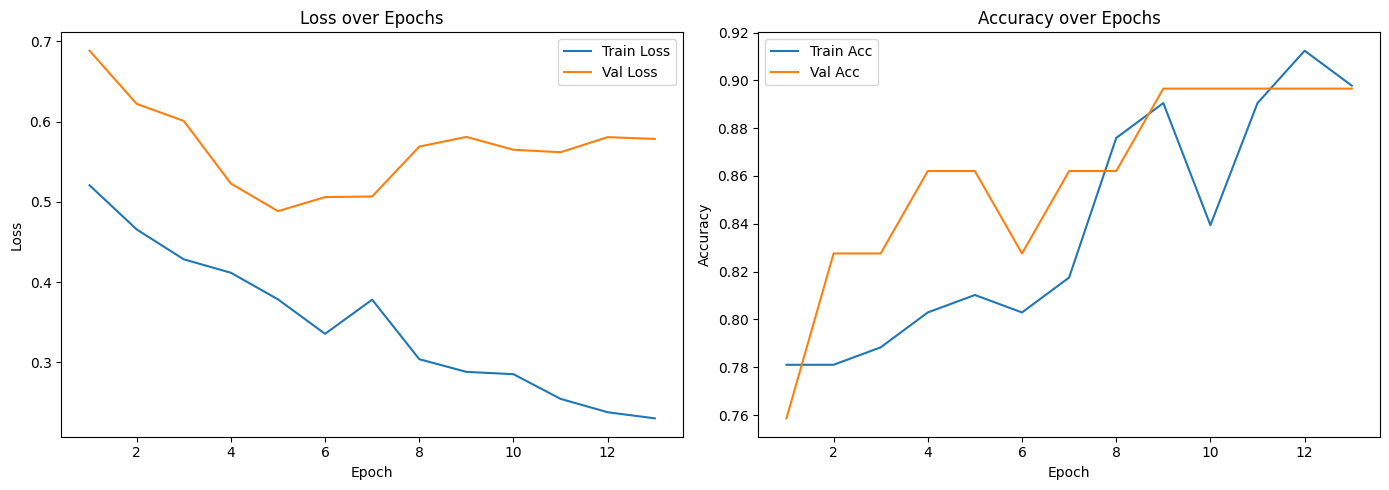

Using 137 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


Test Accuracy: 0.6667
Test precision: 0.5000
Test Recall: 0.4000
Test F1 Score: 0.4444


100%|██████████| 30/30 [00:17<00:00,  1.73it/s]


Started Training CNN+LSTM Deep Model having 12 LSTM features and n_layers=3
Epoch 0 | Train Loss: 0.6503 | Train Acc: 0.5839 | Val Loss: 0.6503 | Val Acc: 0.8276
Epoch 10 | Train Loss: 0.2889 | Train Acc: 0.8394 | Val Loss: 0.5551 | Val Acc: 0.8966
Early stopping triggered.


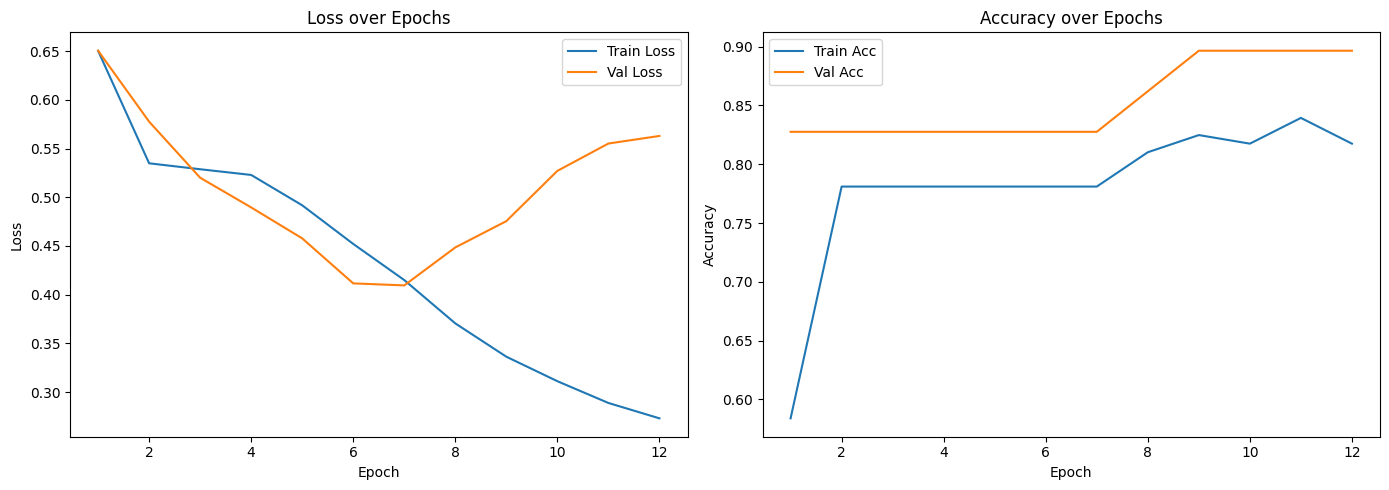

Using 137 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


Test Accuracy: 0.8000
Test precision: 0.6667
Test Recall: 0.8000
Test F1 Score: 0.7273


100%|██████████| 30/30 [00:22<00:00,  1.36it/s]


Started Training CNN+LSTM Deep Model having 12 LSTM features and n_layers=1
Epoch 0 | Train Loss: 0.6046 | Train Acc: 0.6788 | Val Loss: 0.6548 | Val Acc: 0.8276
Epoch 10 | Train Loss: 0.1352 | Train Acc: 0.9635 | Val Loss: 0.6465 | Val Acc: 0.8276
Early stopping triggered.


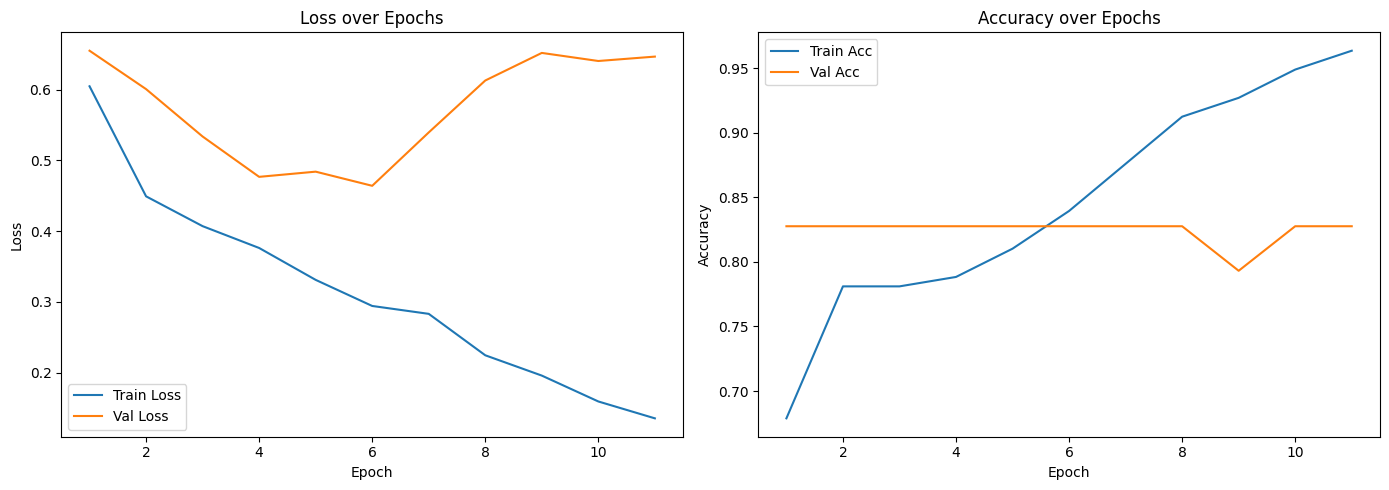

Using 137 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


Test Accuracy: 0.8000
Test precision: 0.7500
Test Recall: 0.6000
Test F1 Score: 0.6667


100%|██████████| 30/30 [00:13<00:00,  2.17it/s]


Started Training CNN+LSTM Deep Model having 12 LSTM features and n_layers=2
Epoch 0 | Train Loss: 0.6145 | Train Acc: 0.6569 | Val Loss: 0.6205 | Val Acc: 0.8276
Epoch 10 | Train Loss: 0.2982 | Train Acc: 0.8759 | Val Loss: 0.5122 | Val Acc: 0.8966
Early stopping triggered.


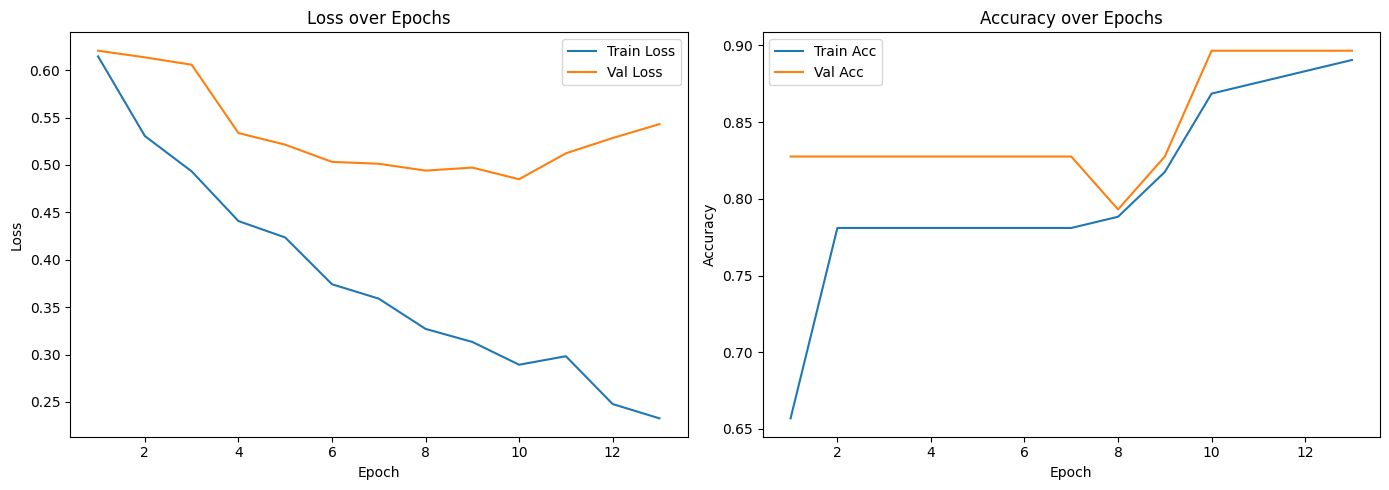

Using 137 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


Test Accuracy: 0.7000
Test precision: 0.6000
Test Recall: 0.3000
Test F1 Score: 0.4000


100%|██████████| 30/30 [00:20<00:00,  1.46it/s]


Started Training CNN+LSTM Deep Model having 12 LSTM features and n_layers=3
Epoch 0 | Train Loss: 0.6160 | Train Acc: 0.6715 | Val Loss: 0.6283 | Val Acc: 0.8276
Epoch 10 | Train Loss: 0.2417 | Train Acc: 0.7810 | Val Loss: 0.8846 | Val Acc: 0.8276
Early stopping triggered.


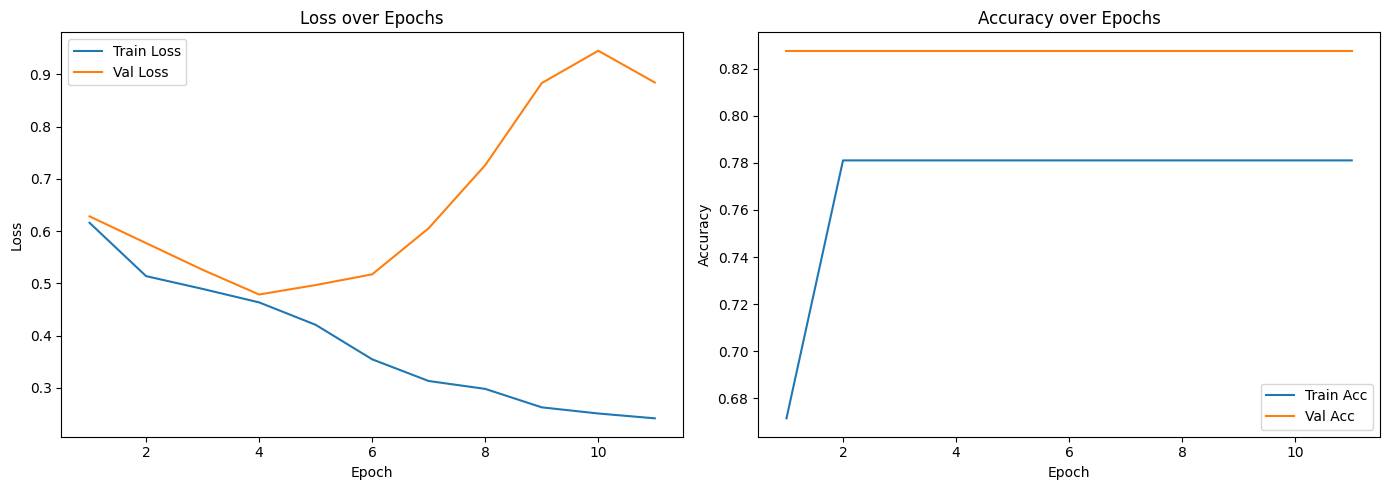

/Users/surafel/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
Using 137 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


Test Accuracy: 0.6667
Test precision: 0.0000
Test Recall: 0.0000
Test F1 Score: 0.0000


100%|██████████| 30/30 [00:28<00:00,  1.07it/s]


In [14]:
run_with_hyperparameters()

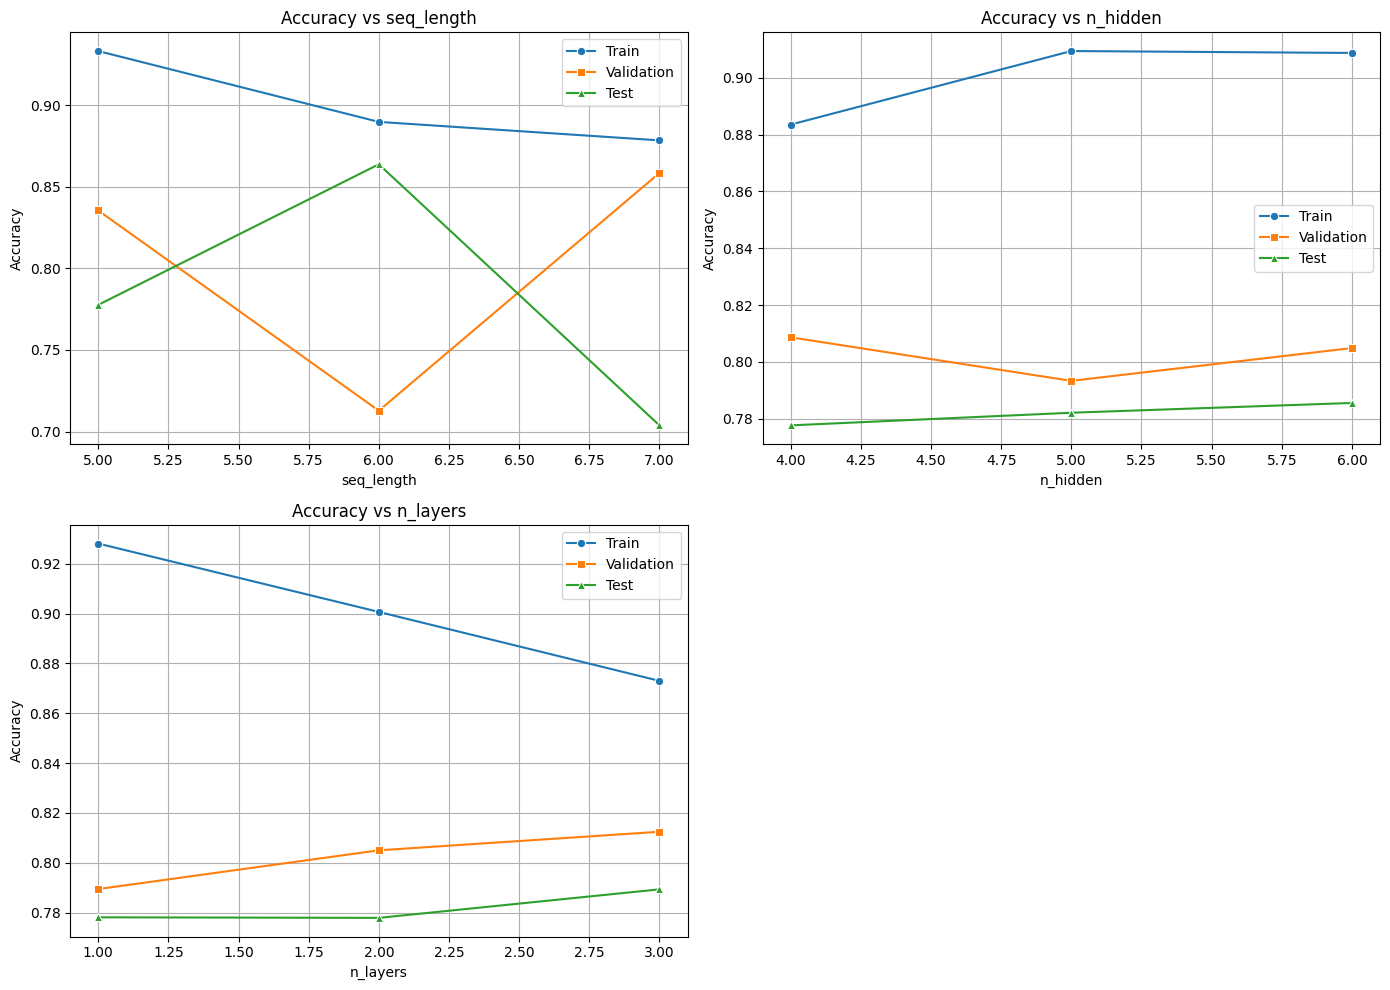

In [15]:
graph_test_results()